In [1]:
import pytensor
pytensor.config.cxx = "/usr/bin/clang++"

import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

---
## Load Data for Prior

In [2]:
past_vote_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="Past Vote", dtype={"FIPS" : str})
del past_vote_df["Weighted % D"]

In [3]:
statewide = past_vote_df[
    ["Total Votes Gov 2021 2P", "Murphy Votes", "RV 2021", "Total Votes GE 2024 2P", "Harris Votes", "RV 2024", "Current RV"]].sum()

In [4]:
statewide["County"] = "New Jersey"
statewide["FIPS"] = "34"

In [5]:
statewide["% Murphy 2P"] = statewide["Murphy Votes"] / statewide["Total Votes Gov 2021 2P"]
statewide["% 2P Turnout 2021"] = statewide["Total Votes Gov 2021 2P"] / statewide["RV 2021"]
statewide["% Harris 2P"] = statewide["Harris Votes"] / statewide["Total Votes GE 2024 2P"]
statewide["% 2P Turnout 2024"] = statewide["Total Votes GE 2024 2P"] / statewide["RV 2024"]
statewide["Margin Murphy Harris"] = statewide["% Harris 2P"] - statewide["% Murphy 2P"]

In [6]:
past_vote_df = pandas.concat([past_vote_df, pandas.DataFrame([statewide])], ignore_index=True)

---
## Load Survey Data

In [80]:
survey_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="GE", parse_dates=["end_date"])

In [81]:
survey_df["Sherrill 2P"] = survey_df["Sherrill 2P"] / 100
survey_df["moe"] = survey_df["moe"] / 100

In [82]:
# survey_df["Sherrill 2P Votes"] = (survey_df["Sherrill 2P"] * survey_df["Sample Size 2P"]).round(0)

In [83]:
survey_df

,FIPS,County,pollster,end_date,population,mode,url,sample_size,moe,credible_interval,partisan,Ciattarelli,Sherrill,Neither,Undecided,Ciattarelli 2P,Sherrill 2P,Margin 2P,Sample Size 2P
0,34,New Jersey,Rutgers-Eagleton,2025-06-16,rv,panel,https://eagletonpoll.rutgers.edu/wp-content/up...,577,0.052,NaN,0,31,51,5,13,37.804878,0.621951,24.390244,473


In [85]:
# TODO: impute these in a smart way

---

In [72]:
coords = {
    "county" : past_vote_df["County"]
}

In [78]:
with pm.Model(coords=coords) as model:
    ## prior
    turnout_pct = pm.Beta("turnout_pct",
                          mu=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].mean(axis=1),
                          sigma=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].std(ddof=1, axis=1),
                          dims="county")

    turnout = pm.Binomial("turnout",
                          p=turnout_pct,
                          n=past_vote_df["Current RV"],
                          dims="county")

    prior_mu = past_vote_df[["% Murphy 2P", "% Harris 2P"]].mean(axis=1)
    prior_sigma = past_vote_df[["% Murphy 2P", "% Harris 2P"]].std(ddof=1, axis=1)
    prior_alpha = ((prior_mu ** 2) * (1 - prior_mu) / (prior_sigma ** 2)) - prior_mu
    prior_beta = (prior_alpha * (1 - prior_mu)) / prior_mu

    # prior_pct_D = pm.Beta("prior_pct_D",
    #                       alpha=prior_alpha,
    #                       beta=prior_beta,
    #                       dims="county")

    ## likelihood
    poll_mu = survey_df[["Sherrill 2P"]].mean(axis=1)
    poll_sigma = survey_df[["moe"]].mean(axis=1)
    poll_alpha = ((poll_mu ** 2) * (1 - poll_mu) / (poll_sigma ** 2)) - poll_mu
    poll_beta = (poll_alpha * (1 - poll_mu)) / poll_mu

    print(prior_alpha + poll_alpha)
    print()
    print(prior_beta + poll_beta)

    # likelihood_pct_D = pm.Beta("likelihood_pct_D",
    #                            alpha=prior_alpha + poll_alpha,
    #                            beta=prior_beta + poll_beta,
    #                            dims="county")

0     184.813632
1            NaN
2            NaN
3            NaN
4            NaN
5            NaN
6            NaN
7            NaN
8            NaN
9            NaN
10           NaN
11           NaN
12           NaN
13           NaN
14           NaN
15           NaN
16           NaN
17           NaN
18           NaN
19           NaN
20           NaN
21           NaN
dtype: float64

0     184.43444
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
6           NaN
7           NaN
8           NaN
9           NaN
10          NaN
11          NaN
12          NaN
13          NaN
14          NaN
15          NaN
16          NaN
17          NaN
18          NaN
19          NaN
20          NaN
21          NaN
dtype: float64


In [77]:
with model:
    idata = pm.sample()#extend_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [turnout_pct, likelihood_pct_D]
>Metropolis: [turnout]


Output()

ParallelSamplingError: Chain 0 failed with: Bad initial energy: SamplerWarning(kind=<WarningType.BAD_ENERGY: 8>, message='Bad initial energy, check any log probabilities that are inf or -inf, nan or very small:\n[nan]\n.Try model.debug() to identify parametrization problems.', level='critical', step=0, exec_info=None, extra=None, divergence_point_source=None, divergence_point_dest=None, divergence_info=None)

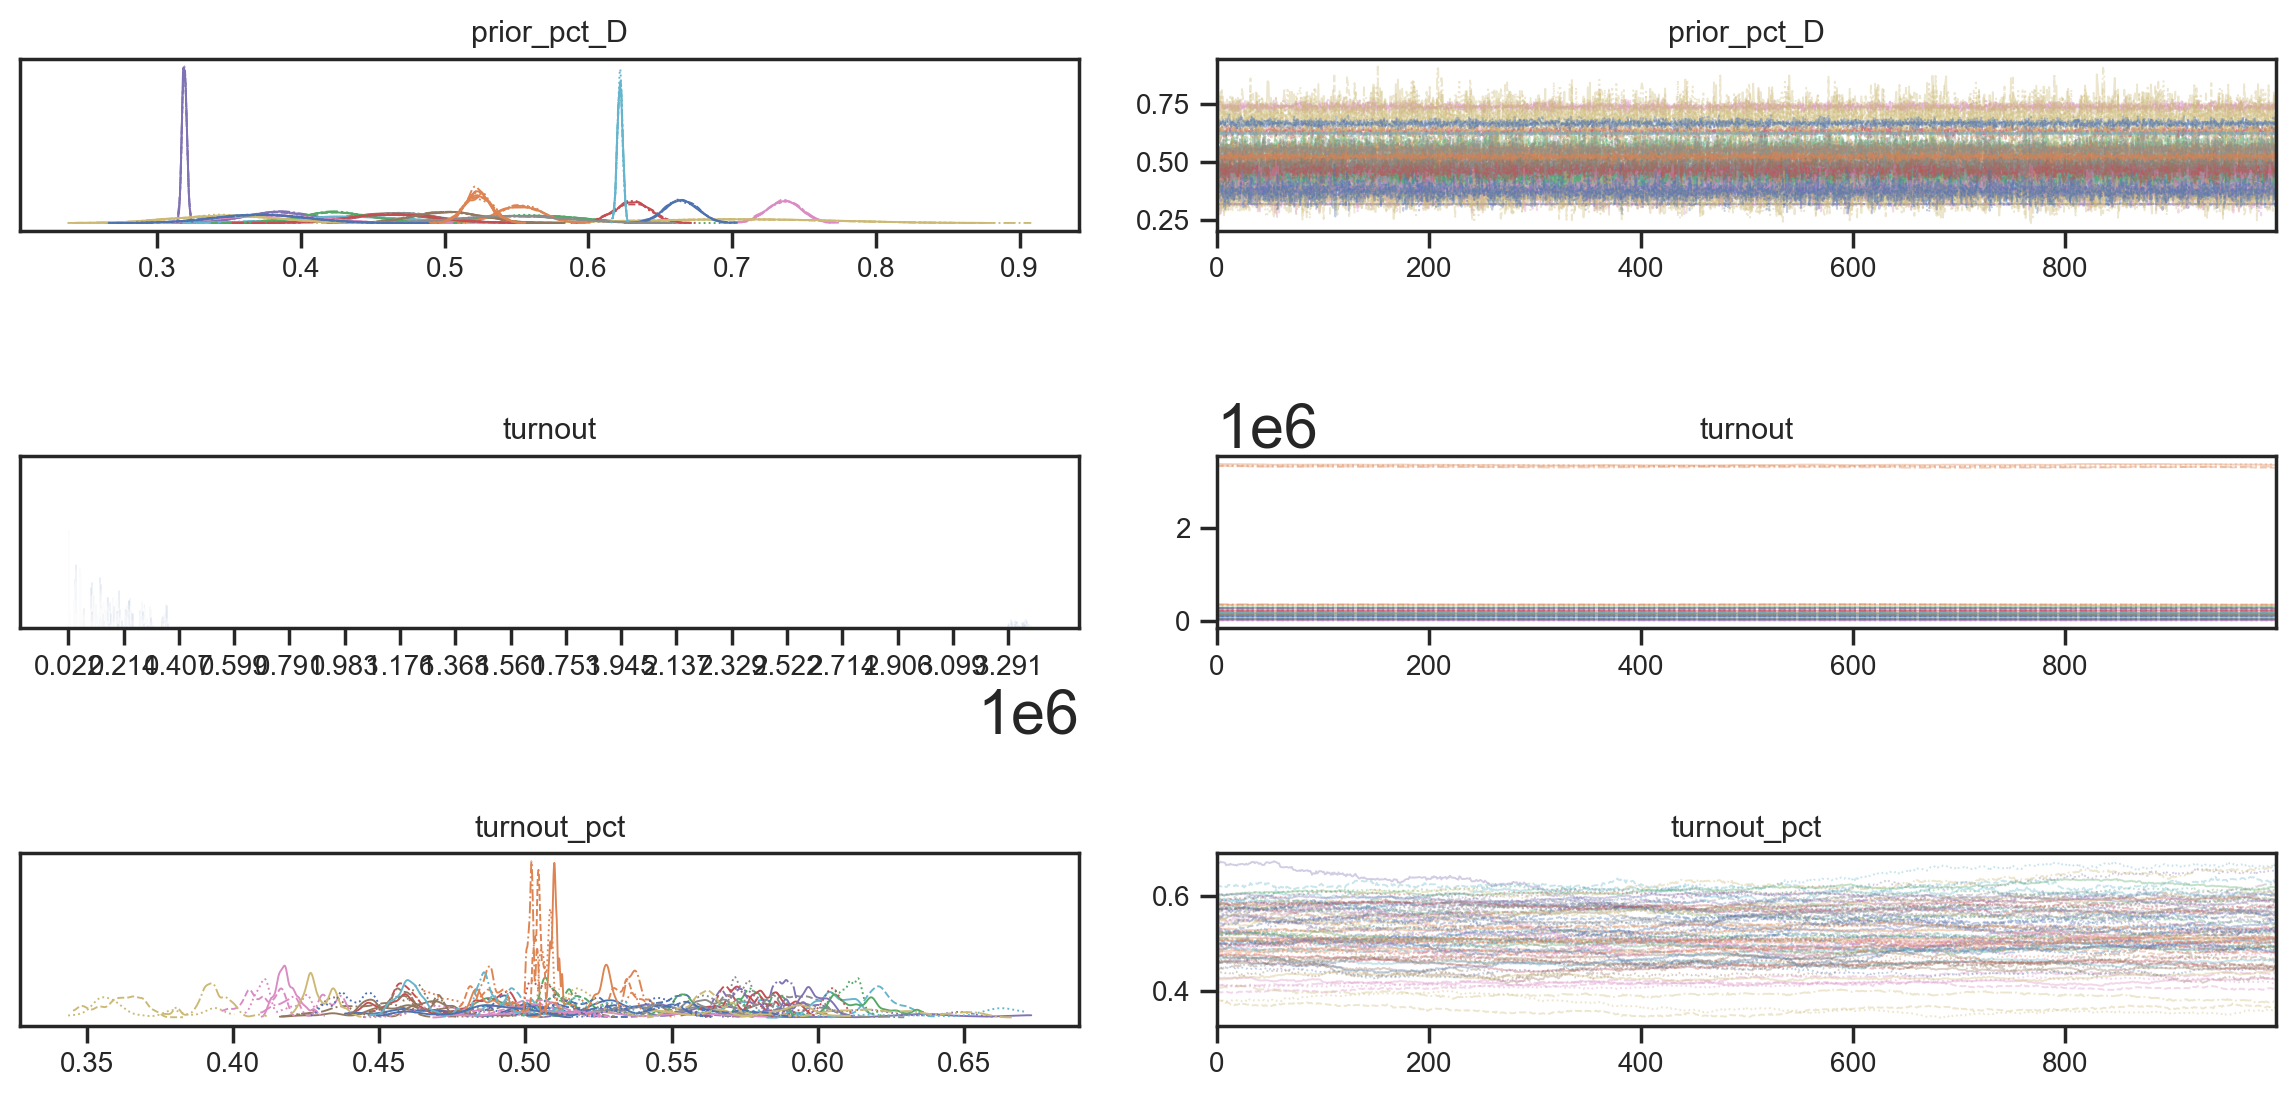

In [35]:
az.plot_trace(idata);
plt.tight_layout()

In [36]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

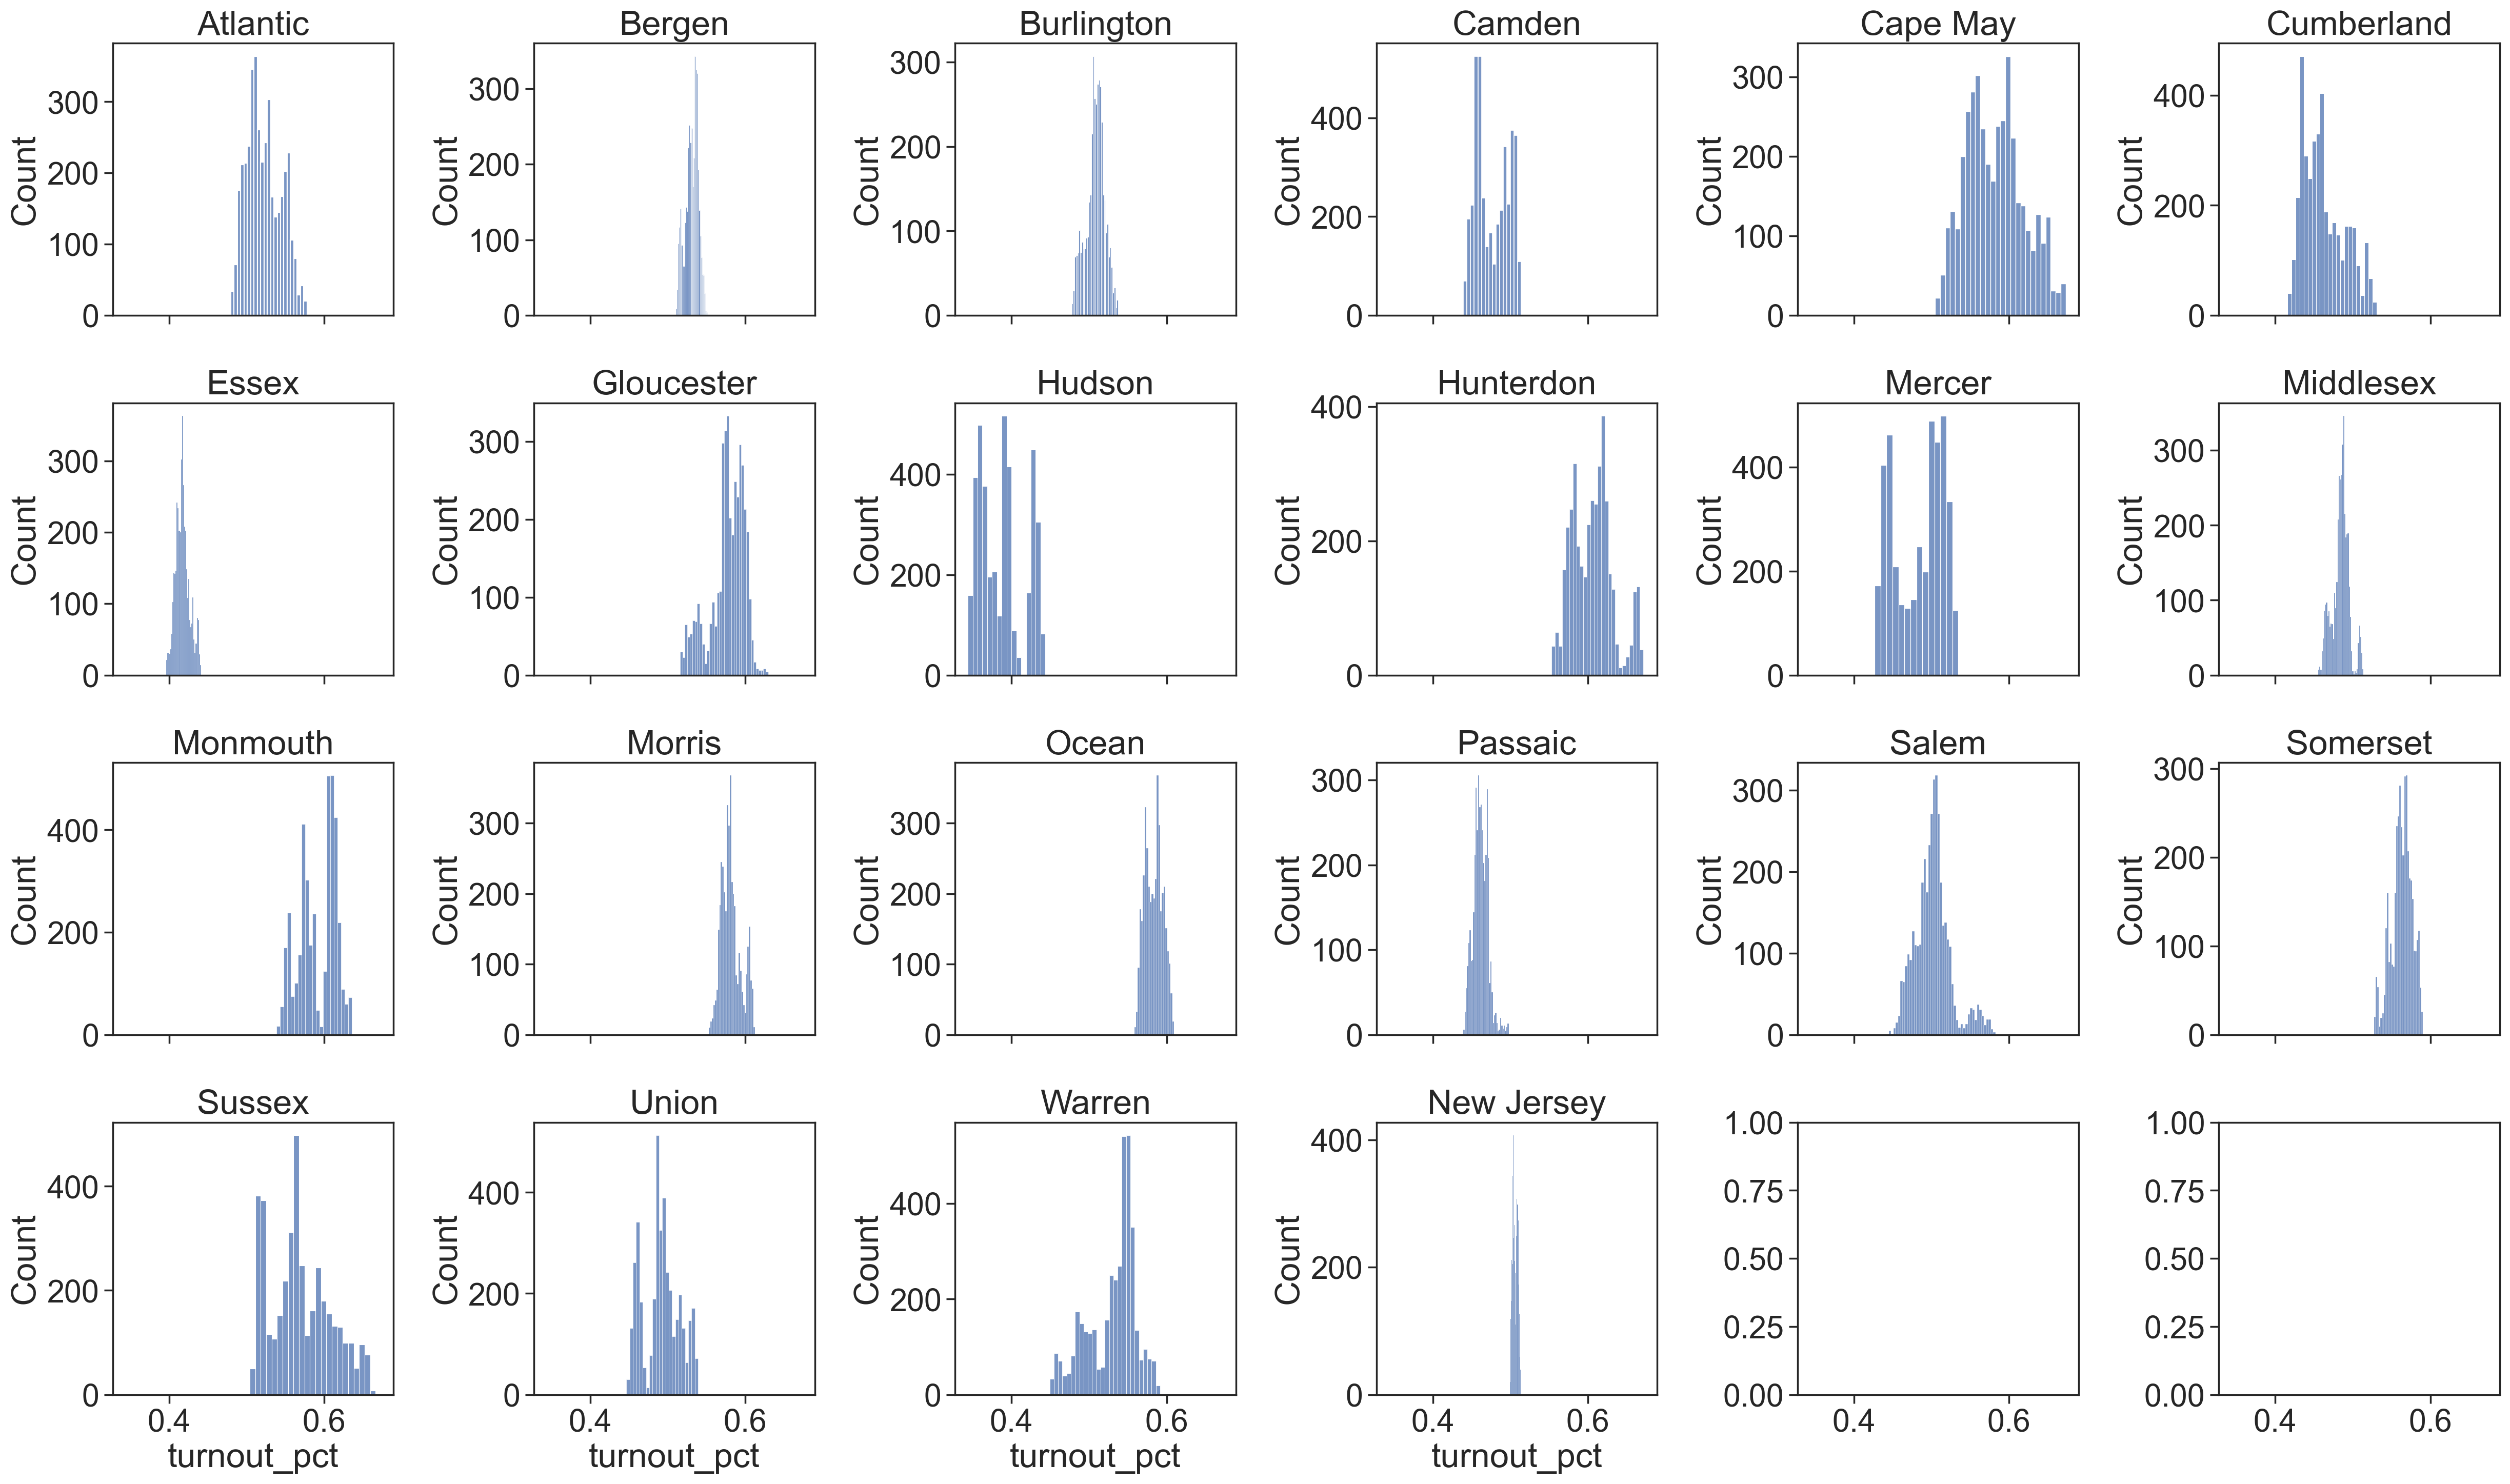

In [37]:
(fig, axs) = plt.subplots(4, 6, sharex=True, sharey=False)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["turnout_pct"].stack(sample=("chain", "draw"))
    sns.histplot(x=post, ax=ax)
    ax.set_title(str(c.values))

plt.tight_layout()

In [38]:
rows = []
for c in idata.posterior.coords["county"]:
    post = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    row = {"County" : str(c.values),
           "Pred" : np.mean(post.values).round(0),
           "Lower" : np.quantile(post.values, 0.025).round(0),
           "Upper" : np.quantile(post.values, 0.975).round(0)}
    rows.append(row)
pandas.DataFrame(rows)

,County,Pred,Lower,Upper
0,Atlantic,106081.0,99051.0,114661.0
1,Bergen,358940.0,347697.0,368702.0
2,Burlington,185943.0,176756.0,193821.0
3,Camden,184744.0,172560.0,197325.0
4,Cape May,44323.0,39581.0,49818.0
5,Cumberland,44311.0,40655.0,49814.0
6,Essex,235379.0,226311.0,246658.0
7,Gloucester,130846.0,118964.0,137804.0
8,Hudson,165020.0,148095.0,185557.0
9,Hunterdon,64515.0,59785.0,70729.0


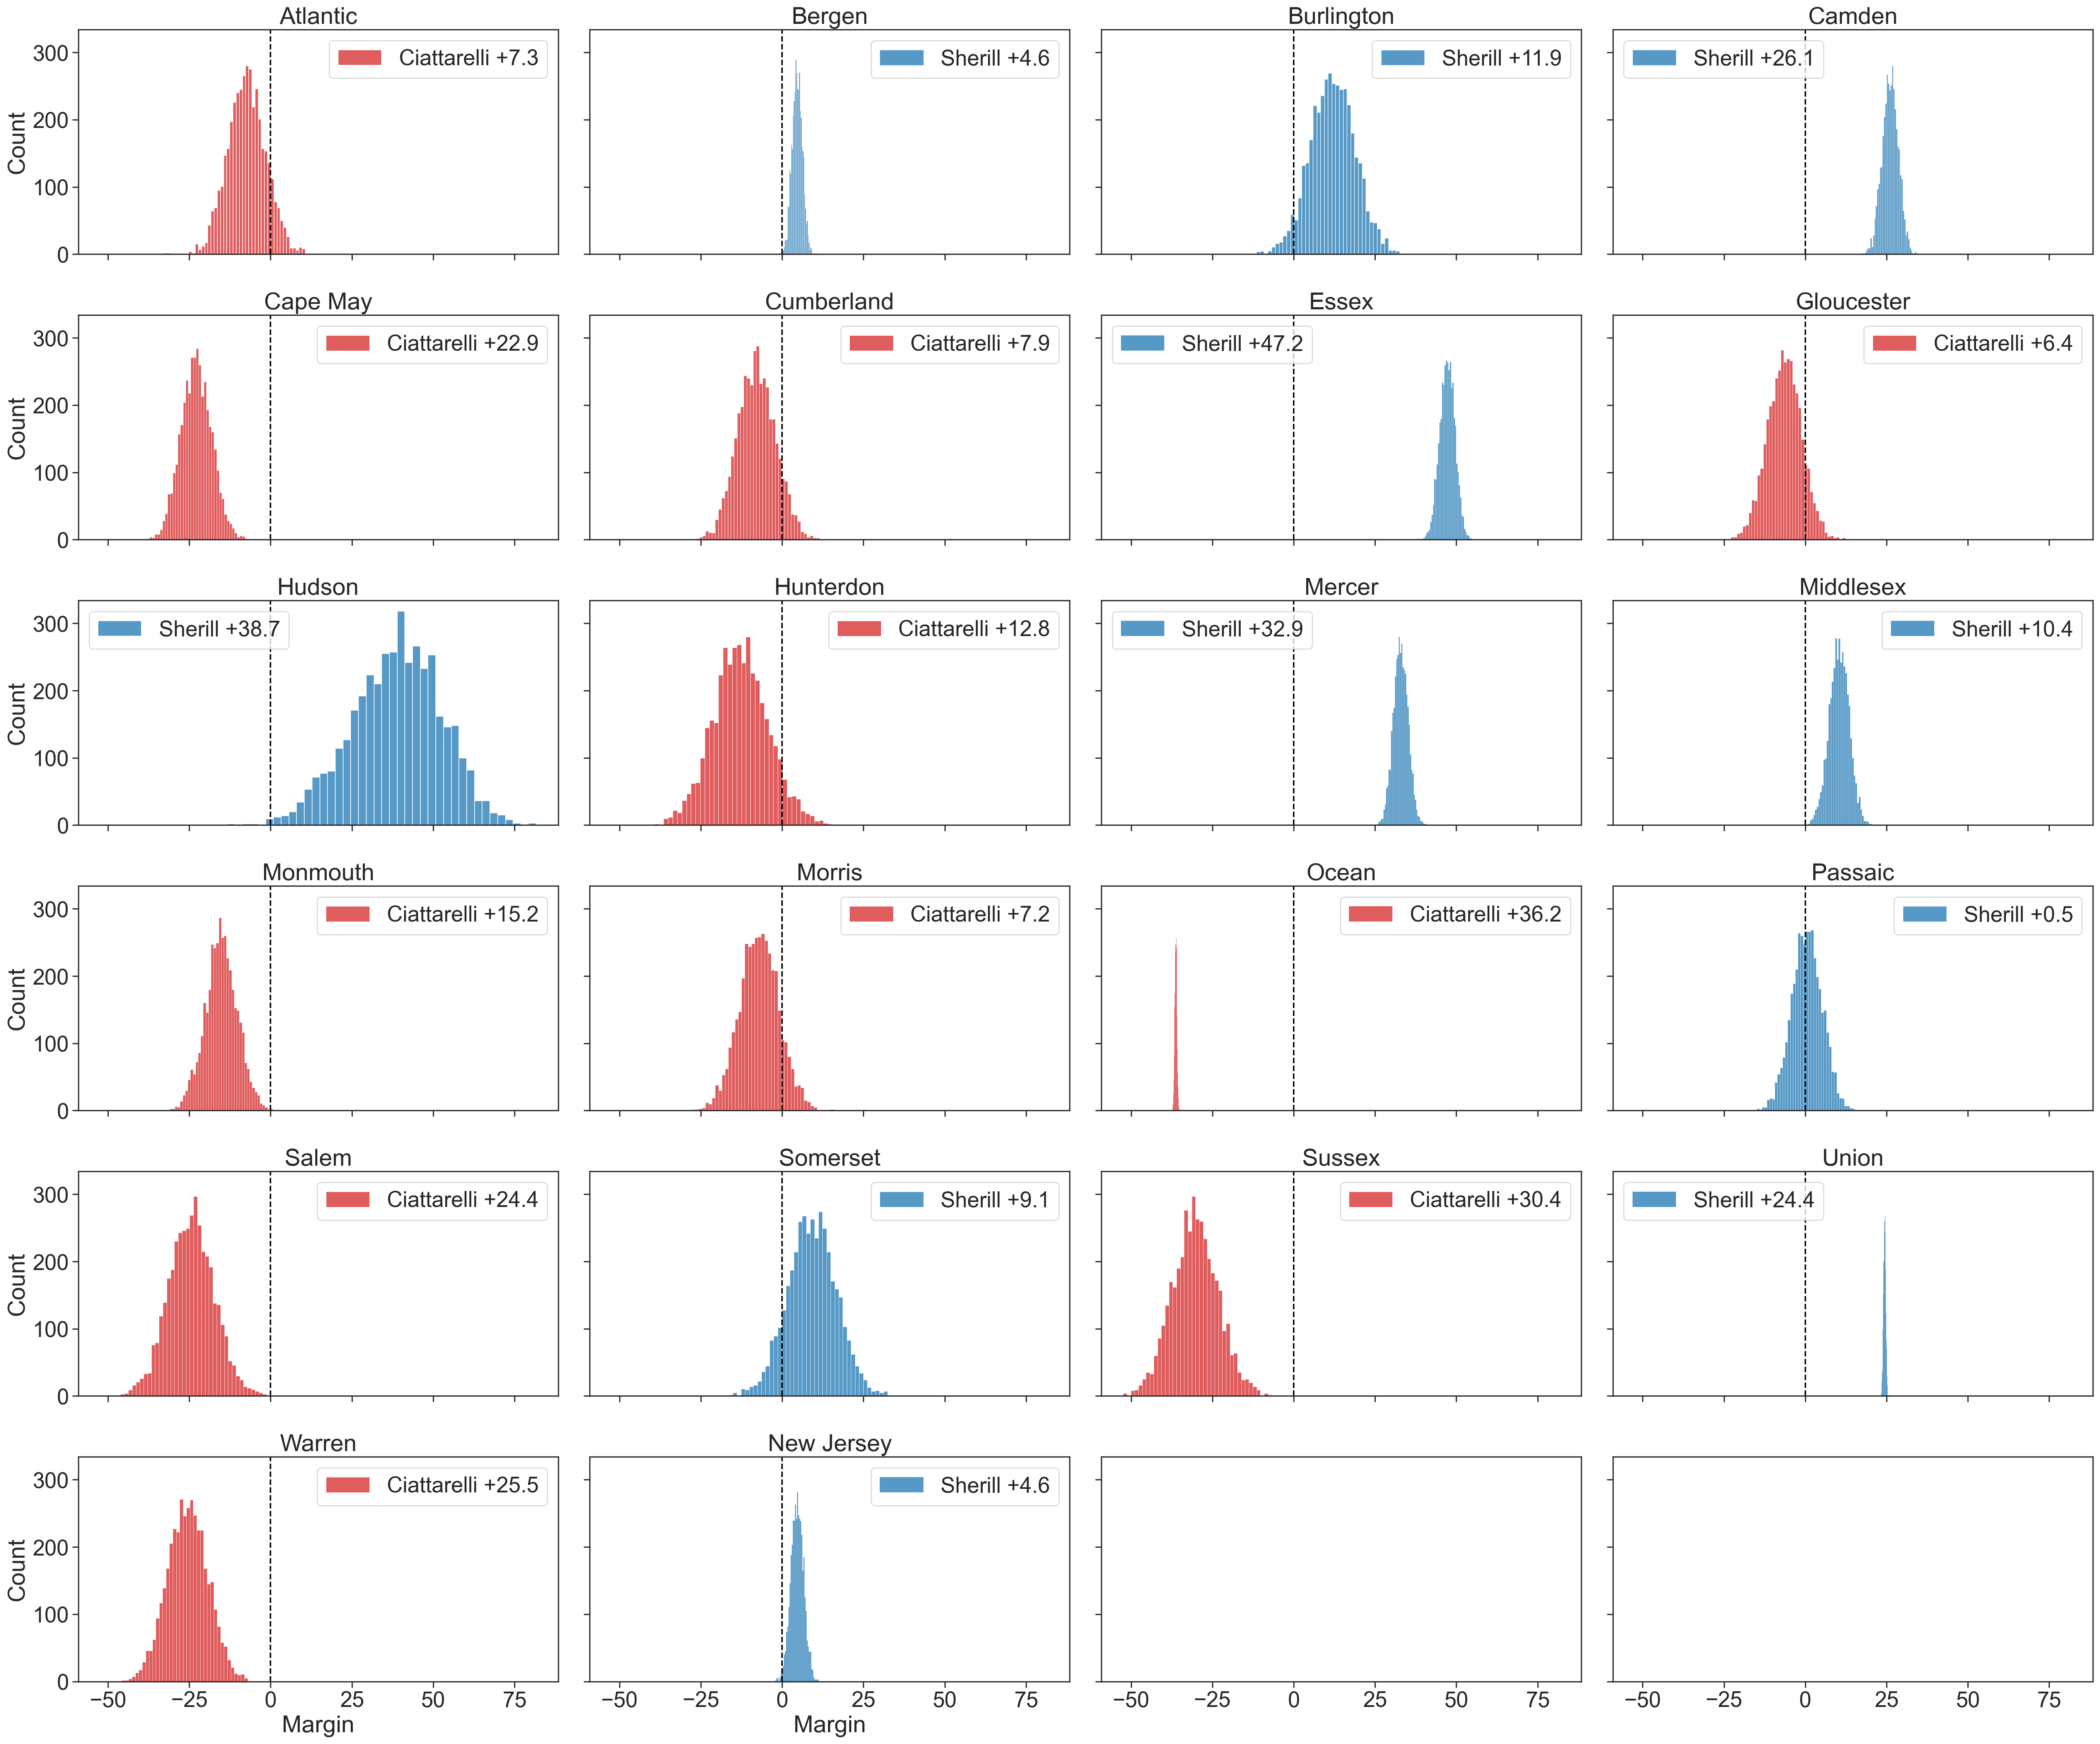

In [39]:
rows = []
(fig, axs) = plt.subplots(6, 4, sharex=True, sharey=True)
fig.set_size_inches(30, 25)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post_D = idata.posterior.sel(county=c)["prior_pct_D"].stack(sample=("chain", "draw"))
    post_R = 1 - post_D
    margin = (post_D - post_R) * 100
    row = {"County" : str(c.values),
           "Pred" : np.mean(margin.values),
           "Lower" : np.quantile(margin.values, 0.025),
           "Upper" : np.quantile(margin.values, 0.975)}
    rows.append(row)
    mean_margin = np.mean(margin.values).mean()

    if mean_margin > 0:
        sns.histplot(x=margin, ax=ax, color="tab:blue", label=f"Sherill +{np.round(mean_margin, 1)}")
    else:
        sns.histplot(x=margin, ax=ax, color="tab:red", label=f"Ciattarelli +{np.round(mean_margin, 1) * -1}")
    
    ax.set_title(str(c.values))
    ax.set_xlabel("Margin")
    ax.legend()
    ax.axvline(0, linestyle="--", color="black")

plt.tight_layout()

In [40]:
pandas.DataFrame(rows).round(1)

,County,Pred,Lower,Upper
0,Atlantic,-7.3,-18.4,4.2
1,Bergen,4.6,1.6,7.7
2,Burlington,11.9,-1.7,25.6
3,Camden,26.1,21.3,30.9
4,Cape May,-22.9,-31.8,-13.6
5,Cumberland,-7.9,-19.0,3.7
6,Essex,47.2,42.7,51.7
7,Gloucester,-6.4,-16.8,4.0
8,Hudson,38.7,10.5,63.6
9,Hunterdon,-12.8,-29.5,4.6
